In [1]:
# Import packages
import math as m
import numpy as np
from scipy.integrate import quad, trapezoid, simpson
import matplotlib.pyplot as plt
import csv

In [2]:
# Define constants
kB = 1.38066e-23 #J/K
h = 6.62618e-34 #J*s
m_n = 1.00866501 *1.660566e-27 #kg
v_0 = 2200 #m/s
eV = 1.602189e-19
E_0_J = 1/2 * m_n * v_0**2 #J
E_0 = E_0_J / eV #eV

In [3]:
# Test case: 197Au
# Resonance parameters
E_r_197Au = 4.906 #eV
Gamma_197Au = 137.7/1000 #eV

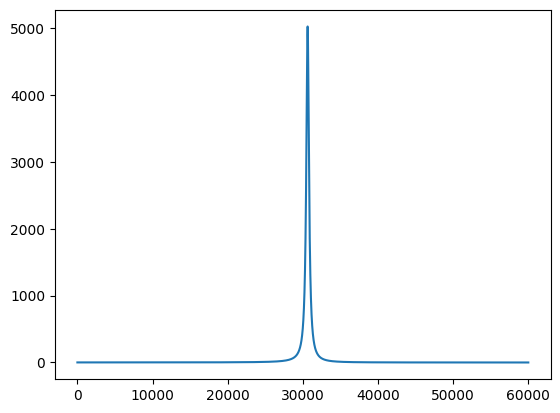

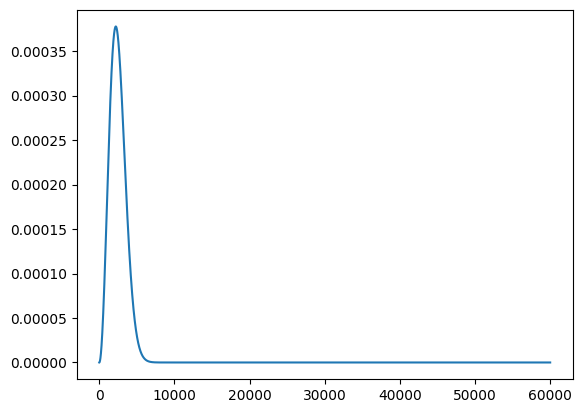

In [4]:
# Define functions
# Lorentzian resonance; Molnar eqn. 1-3
def del_0(v,Er,G):
    E = 1/2 * m_n * v**2 / eV #eV
    return ((Er - E_0)**2 + G**2/4)/((Er - E)**2 + G**2/4)
del_0_vector = np.vectorize(del_0)

# Neutron density, given Maxwellian distribution; Molnar Table 1-1
def p(T,v):
    v_T = m.sqrt(2*kB*T/m_n)
    return 4/m.sqrt(m.pi) * m.exp(-v**2/v_T**2) * v**2/v_T**3 

# Plot
vel = range(60000)
d = []
pt = []
for v in vel:
    d.append(del_0(v,E_r_197Au,Gamma_197Au))
    pt.append(p(293,v))
plt.plot(vel,d)
plt.show()

plt.plot(vel,pt)
plt.show()

In [5]:
# Integrate over velocity to find Westcott g-factor (Molnar eqn. 1-5)
# Define integrand
def g_int(v,T,Er,G):
    return del_0(v,Er,G)*p(T,v)
g_int_vector = np.vectorize(g_int)
# Perform numerical integration
def g_maxwellian(T,Er,G):
    v_neutron = np.linspace(0,100000,100000)
    return trapezoid(g_int_vector(v_neutron,T,Er,G), v_neutron)

In [6]:
# The above appears to create the correct functions, so now to evaluate g(T) for 197Au to check against Appendix 8
T_list = [30, 70, 100, 150, 200, 293, 320] # K
print("197Au")
[print("T={0}K;   g={1:.3f}".format(T,g_maxwellian(T,E_r_197Au,Gamma_197Au))) for T in T_list][0]

197Au
T=30K;   g=0.991
T=70K;   g=0.993
T=100K;   g=0.995
T=150K;   g=0.998
T=200K;   g=1.000
T=293K;   g=1.005
T=320K;   g=1.007


In [7]:
# Spot on the values in Table 8-2!  Next try 193Ir.
# Resonance parameters
E_r_193Ir = 1.3 #eV
Gamma_193Ir = 83.9/1000 #eV
print("193Ir")
[print("T={0}K;   g={1:.3f}".format(T,g_maxwellian(T,E_r_193Ir,Gamma_193Ir))) for T in T_list][0]

193Ir
T=30K;   g=0.967
T=70K;   g=0.975
T=100K;   g=0.981
T=150K;   g=0.991
T=200K;   g=1.002
T=293K;   g=1.022
T=320K;   g=1.028


In [8]:
# Now to try a harder one, with a negative-energy resonance: 83Kr
# Resonance parameters
E_r_83Kr = -3.9 #eV
Gamma_83Kr = 245/1000 #eV
print("83Kr")
[print("T={0}K;   g={1:.3f}".format(T,g_maxwellian(T,E_r_83Kr,Gamma_83Kr))) for T in T_list][0]

83Kr
T=30K;   g=1.011
T=70K;   g=1.008
T=100K;   g=1.006
T=150K;   g=1.003
T=200K;   g=1.000
T=293K;   g=0.994
T=320K;   g=0.992


In [9]:
# That's correct, so now to try one with a multiple resonances: 175Lu
# Resonance parameters
E_r_1_175Lu = 2.59 #eV
Gamma_1_175Lu = 71/1000 #eV
E_r_2_175Lu = 4.75 #eV
Gamma_2_175Lu = 65/1000 #eV

# Redefine functions to accomodate both one and two resonance cases
def del_0(v,Er_1,G_1,Er_2=None,G_2=None):
    E = 1/2 * m_n * v**2 / eV #eV
    if (Er_2 != None) & (G_2 != None):
        return 1/2*(((Er_1 - E_0)**2 + G_1**2/4)/((Er_1 - E)**2 + G_1**2/4) + ((Er_2 - E_0)**2 + G_2**2/4)/((Er_2 - E)**2 + G_2**2/4))
    else:
        return ((Er_1 - E_0)**2 + G_1**2/4)/((Er_1 - E)**2 + G_1**2/4)
del_0_vector = np.vectorize(del_0)

def g_int(v,T,Er_1,G_1,Er_2=None,G_2=None):
    return del_0(v,Er_1,G_1,Er_2=None,G_2=None)*p(T,v)
g_int_vector = np.vectorize(g_int)

def g_maxwellian(T,Er_1,G_1,Er_2=None,G_2=None):
    v_neutron = np.linspace(0,100000,100000)
    return trapezoid(g_int_vector(v_neutron,T,Er_1,G_1,Er_2=None,G_2=None), v_neutron)

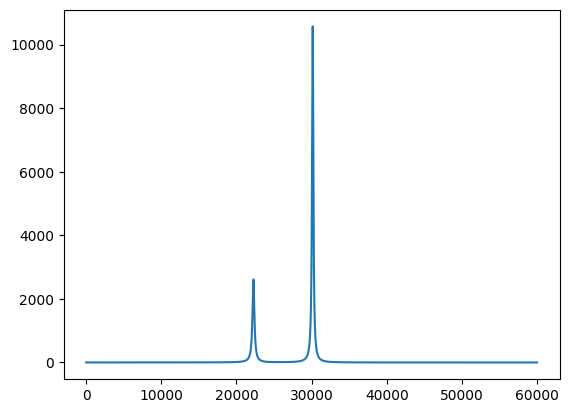

In [10]:
# Plot to make sure it looks right
vel = range(60000)
d = []
for v in vel:
    d.append(del_0(v, E_r_1_175Lu, Gamma_1_175Lu,E_r_2_175Lu,Gamma_2_175Lu))
plt.plot(vel,d)
plt.show()

In [11]:
print("175Lu")
[print("T={0}K;   g={1:.3f}".format(T,g_maxwellian(T,E_r_1_175Lu,Gamma_1_175Lu,E_r_2_175Lu,Gamma_2_175Lu))) for T in T_list][0]

175Lu
T=30K;   g=0.984
T=70K;   g=0.987
T=100K;   g=0.990
T=150K;   g=0.996
T=200K;   g=1.001
T=293K;   g=1.010
T=320K;   g=1.013


In [12]:
# Now on to 187Re
# Resonance parameters (from Molnar Handbook)
E_r_1_187Re = -4.03 #eV
Gamma_1_187Re = 74.4/1000 #eV
E_r_2_187Re = 4.41 #eV
Gamma_2_187Re = 54.9/1000 #eV

# Evaluate the g-factors
print("187Re; Maxwellian neutron spectrum")
[print("T={0}K;   g={1:.3f}".format(T,g_maxwellian(T,E_r_1_187Re,Gamma_1_187Re,E_r_2_187Re,Gamma_2_187Re))) for T in T_list][0]

187Re; Maxwellian neutron spectrum
T=30K;   g=1.011
T=70K;   g=1.008
T=100K;   g=1.006
T=150K;   g=1.003
T=200K;   g=1.000
T=293K;   g=0.994
T=320K;   g=0.992


In [13]:
# Trying resonance parameters from Mughabghab (2018) for 187Re
# Resonance parameters
E_r_1_187Re = -3.94 #eV
Gamma_1_187Re = 57.8/1000 #eV
E_r_2_187Re = 4.416 #eV
Gamma_2_187Re = 54.6/1000 #eV

# Evaluate the g-factors
print("187Re; Maxwellian neutron spectrum")
[print("T={0}K;   g={1:.3f}".format(T,g_maxwellian(T,E_r_1_187Re,Gamma_1_187Re,E_r_2_187Re,Gamma_2_187Re))) for T in T_list][0]

187Re; Maxwellian neutron spectrum
T=30K;   g=1.011
T=70K;   g=1.008
T=100K;   g=1.006
T=150K;   g=1.003
T=200K;   g=1.000
T=293K;   g=0.994
T=320K;   g=0.992


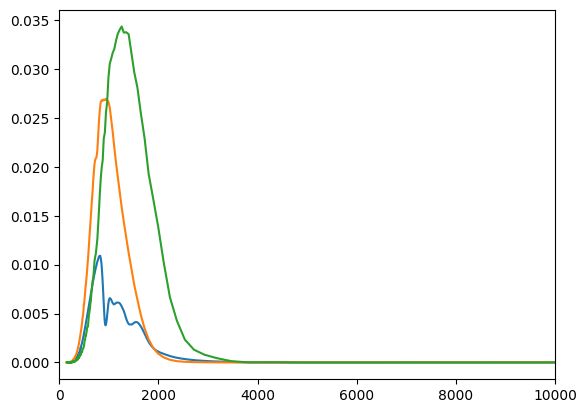

In [14]:
# These differ by ~1% from the values in the IAEA Database of Prompt Gamma Rays (there's no value in Molnar for 187Re), but the behavior is similar
# Next to try the cold neutron source case...first need to import the neutron spectra from the CSV files (built from the spectra Laszlo sent) and convert them to velocity distributions
with open('bnc_cold_spectrum_2015.csv',mode='r', encoding='utf-8-sig') as file:
    csvFile = csv.reader(file)
    next(csvFile, None)  # Skip header line
    vn_c_2015 = []
    dndv_c_2015 = []
    for lines in csvFile:
        vn_c_2015.append(m.sqrt(2*float(lines[0])*1.602e-19/m_n))
        dndv_c_2015.append(float(lines[1]))

with open('bnc_cold_spectrum_2002.csv',mode='r', encoding='utf-8-sig') as file:
    csvFile = csv.reader(file)
    next(csvFile, None)  # Skip header line
    vn_c_2002 = []
    dndv_c_2002 = []
    for lines in csvFile:
        vn_c_2002.append(m.sqrt(2*float(lines[0])*1.602e-19/m_n))
        dndv_c_2002.append(float(lines[1]))

with open('bnc_thermal_spectrum_2002.csv',mode='r', encoding='utf-8-sig') as file:
    csvFile = csv.reader(file)
    next(csvFile, None)  # Skip header line
    vn_t_2002 = []
    dndv_t_2002 = []
    for lines in csvFile:
        vn_t_2002.append(m.sqrt(2*float(lines[0])*1.602e-19/m_n))
        dndv_t_2002.append(float(lines[1]))

# Plot velocity distributions (NB: not normalized)
plt.plot(vn_c_2015, dndv_c_2015)
plt.plot(vn_c_2002, dndv_c_2002)
plt.plot(vn_t_2002, dndv_t_2002)
ax = plt.gca()
ax.set_xlim([0,10000])
#ax.set_yscale('log')
plt.show()

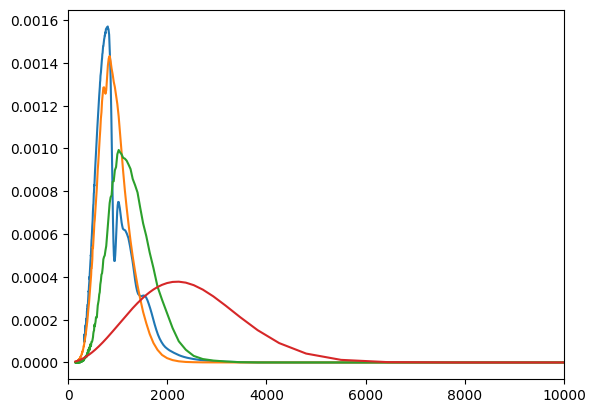

In [15]:
# Define p(T,v) function to work with arbitrary neutron flux distributions (Molnar Table 1-1)
def p_arb_spectrum(T,vn=np.linspace(1,100000,100000),phi_vn=np.ones(100000)/100000):
    p_array = []
    for i in range(len(vn)):
        vt = m.sqrt(2 * kB * T / m_n)
        p_array.append(2 * vt * phi_vn[i] / (m.sqrt(m.pi) * vn[i]))
    p_array = np.array(p_array)
    N = trapezoid(p_array, vn)  # Normalization factor, to ensure integral of p(T,v) integrates to 1 (Molnar p. 12)
    return p_array/N

# Plot
pt_c_2015 = p_arb_spectrum(140,vn_c_2015,dndv_c_2015)
pt_c_2002 = p_arb_spectrum(140,vn_c_2002,dndv_c_2002)
pt_t_2002 = p_arb_spectrum(293,vn_t_2002,dndv_t_2002)
pt_maxwell_293 = []
for i in range(len(vn_t_2002)):
    pt_maxwell_293.append(p(293,vn_t_2002[i]))
plt.plot(vn_c_2015, pt_c_2015)
plt.plot(vn_c_2002, pt_c_2002)
plt.plot(vn_t_2002, pt_t_2002)
plt.plot(vn_t_2002, pt_maxwell_293)
ax = plt.gca()
ax.set_xlim([0,10000])
#ax.set_yscale('log')
plt.show()

In [16]:
# Integrate to get the g factor
def g_arb_spectrum(T,Er_1,G_1,Er_2=None,G_2=None,vn=np.linspace(1,100000,100000),phi_vn=np.ones(100000)/100000):
    d = []
    for i in range(len(vn)):
        d.append(del_0(vn[i],Er_1,G_1,Er_2,G_2))
    d = np.array(d)
    return trapezoid(d * p_arb_spectrum(T,vn,phi_vn), vn)

print("187Re; BNC (supermirror-guided) cold-neutron spectrum, 2015")
print("T=140K;   g={0}".format(g_arb_spectrum(140,E_r_1_187Re,Gamma_1_187Re,E_r_2_187Re,Gamma_2_187Re, vn_c_2015,dndv_c_2015)))

187Re; BNC (supermirror-guided) cold-neutron spectrum, 2015
T=140K;   g=1.0005470397305019


In [17]:
# Evaluate 187Re g-factors for older (2002) spectra
print("187Re; BNC (supermirror-guided) cold-neutron spectrum, 2002")
print("T=140K;   g={0}".format(g_arb_spectrum(140,E_r_1_187Re,Gamma_1_187Re,E_r_2_187Re,Gamma_2_187Re, vn_c_2002,dndv_c_2002)))
print("")
print("187Re; BNC (supermirror-guided) thermal-neutron spectrum, 2002")
print("T=293K;   g={0}".format(g_arb_spectrum(293,E_r_1_187Re,Gamma_1_187Re,E_r_2_187Re,Gamma_2_187Re, vn_t_2002,dndv_t_2002)))

187Re; BNC (supermirror-guided) cold-neutron spectrum, 2002
T=140K;   g=1.0005870573715043

187Re; BNC (supermirror-guided) thermal-neutron spectrum, 2002
T=293K;   g=1.0003775927243805


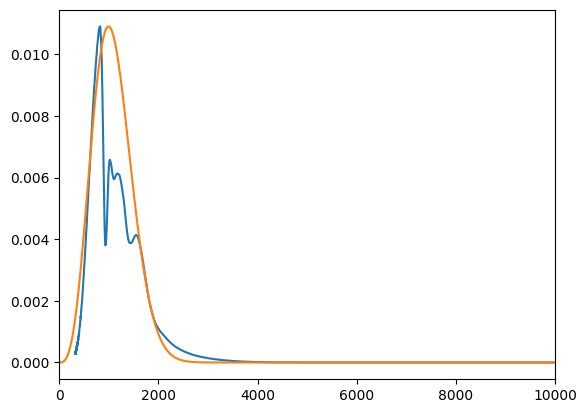

193Ir; Maxwellian spectrum, using arbitrary spectrum method
T=30K;   g=0.967
T=70K;   g=0.975
T=100K;   g=0.981
T=150K;   g=0.991
T=200K;   g=1.002
T=293K;   g=1.022
T=320K;   g=1.028

193Ir; Maxwellian spectrum, using nominal method
T=30K;   g=0.967
T=70K;   g=0.975
T=100K;   g=0.981
T=150K;   g=0.991
T=200K;   g=1.002
T=293K;   g=1.022
T=320K;   g=1.028


In [18]:
# Test: try using the new function to generate a Maxwellian g-factor, and compare with nominal (Maxwellian only) method
def phi_maxwellian(T,vn):
    phi = []
    vt = m.sqrt(2*kB*T/m_n)
    for v in vn:
        phi.append(2 * m.exp(-v**2/vt**2) * v**3/vt**4)
    return np.array(phi)

vn_maxwell = np.linspace(1,100000,100000)

# Plot flux distributions with Maxwellian (NB: not normalized; Maxwellian scaled only to compare with BNC spectra)
plt.plot(vn_c_2015, dndv_c_2015)
#plt.plot(vn_c_2002, dndv_c_2002)
#plt.plot(vn_t_2002, dndv_t_2002)
plt.plot(vn_maxwell, phi_maxwellian(40,vn_maxwell)*10.8)
ax = plt.gca()
ax.set_xlim([0,10000])
#ax.set_yscale('log')
plt.show()

print("193Ir; Maxwellian spectrum, using arbitrary spectrum method")
[print("T={0}K;   g={1:.3f}".format(T,g_arb_spectrum(T,E_r_193Ir,Gamma_193Ir,None,None,vn_maxwell,phi_maxwellian(T,vn_maxwell)))) for T in T_list][0]
print("")
print("193Ir; Maxwellian spectrum, using nominal method")
[print("T={0}K;   g={1:.3f}".format(T,g_maxwellian(T,E_r_193Ir,Gamma_193Ir))) for T in T_list][0]

In [19]:
# See how much the spectrum makes a difference on 193Ir, which has a low-energy resonance
print("193Ir; BNC (supermirror-guided) cold-neutron spectrum, 2015")
print("T=140K;   g={0:.3f}".format(g_arb_spectrum(140,E_r_193Ir,Gamma_193Ir,None,None,vn_c_2015,dndv_c_2015)))
print("")
print("193Ir; BNC (supermirror-guided) cold-neutron spectrum, 2002")
print("T=140K;   g={0:.3f}".format(g_arb_spectrum(140,E_r_193Ir,Gamma_193Ir,None,None,vn_c_2002,dndv_c_2002)))
print("")
print("193Ir; BNC (supermirror-guided) thermal-neutron spectrum, 2002")
print("T=293K;   g={0:.3f}".format(g_arb_spectrum(293,E_r_193Ir,Gamma_193Ir,None,None,vn_t_2002,dndv_t_2002)))

193Ir; BNC (supermirror-guided) cold-neutron spectrum, 2015
T=140K;   g=0.970

193Ir; BNC (supermirror-guided) cold-neutron spectrum, 2002
T=140K;   g=0.969

193Ir; BNC (supermirror-guided) thermal-neutron spectrum, 2002
T=293K;   g=0.976
